<a href="https://colab.research.google.com/github/stiltnerag/INFO648/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Part 1: Data Preparation

In [9]:
df=pd.read_csv('/content/churn_synthetic_600_new.csv')

In [10]:
data.head()

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,23,77.81,Month-to-Month,Credit Card,1
1,C0002,0,33,69.65,One-Year,Credit Card,1
2,C0003,1,22,64.27,Month-to-Month,Electronic Check,2
3,C0004,1,4,66.30,Month-to-Month,Credit Card,3
4,C0005,0,2,60.82,One-Year,Bank Transfer,1


In [11]:
df.describe()

,Churn,TenureMonths,MonthlyCharge,SupportCalls
count,600.000000,600.000000,600.000000,600.000000
mean,0.176667,37.270000,71.661650,1.293333
std,0.381705,20.340189,20.113612,1.061052
min,0.000000,1.000000,25.000000,0.000000
25%,0.000000,21.000000,58.147500,0.000000
50%,0.000000,37.000000,71.350000,1.000000
75%,0.000000,54.000000,84.717500,2.000000
max,1.000000,72.000000,134.620000,6.000000


In [12]:
model_df=df

Numeric:
*   Churn
*   TenureMonths
*   MonthlyCharge
*   SupportCalls

Categorical:
*   CustomerID
*   ContractType
*   PaymentMethod




In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

numeric_features = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
categorical_features = ['ContractType', 'PaymentMethod']

preprocess = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder='drop'
)

Preprocessing is still required so we can handle missing values. we also need to preprocess so that we can convert the categorical variables into a numeric input the decision tree can process. We also want to manage imbalance, so that the tree does not automatically optimize for the majority class.

#Part 2: Decision Tree Model Construction

In [21]:
X = model_df.drop(columns=['Churn', 'CustomerID'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


model = Pipeline([
    ("prep", preprocess),
    ("clf",DecisionTreeClassifier(max_depth=12,min_samples_leaf=18,random_state=42))
])

In [34]:
model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['TenureMonths',
                                                   'MonthlyCharge',
                                                   'SupportCalls']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=12, min_samples_leaf=18,
                                        random_state=42))])

In [36]:
y_pred = model.predict(X_test)

Decision trees make prediction by asking a sequence of yes/no questions basically a flow chart learned from data. Logistic regression output is a continous probability score between 0 and 1. Logistic regression is linear and decision trees are non-linear.

#Part 3: Default Threshold Evaluation

In [37]:
y_pred=model.predict(X_test)

In [38]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1])

In [40]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,model.predict_proba(X_test)[:,1])

np.float64(0.7361972704714641)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
#Actual first
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[118   6]
 [ 19   7]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       124
           1       0.54      0.27      0.36        26

    accuracy                           0.83       150
   macro avg       0.70      0.61      0.63       150
weighted avg       0.81      0.83      0.81       150



The accuracy is showing 83%, but we notice a class imbalance out of 150 total customers 124 stayed and only 26 churned. Our recall for this model is 27%, so the amount of customers we actually caught who churned was extremely low catching only 7 out of 26. Our model is only right at predicting a customer as a churn risk 54% of the time, this is important if we're spending a large amount on customer incentives.

#Part 4: ROC Curve and AUC Interpretation

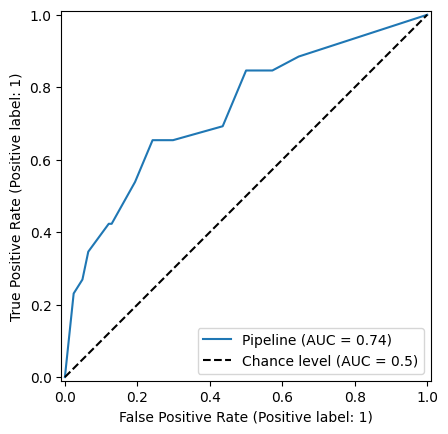

In [42]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model,X_test,y_test,plot_chance_level=True)

1. What does the ROC curve represent in a classification model? ROC shows the true positive and false positive rate relationship across all possible classification thresholds.

2. What does the Area Under the Curve (AUC) measure? ranking quality, anything over 0.90+ is excellent

3. What does the AUC for this model tell us?? The AUC of 0.74 which is considered decent or useable is telling us that there is a 74% chance our model will assign a higher probability of churn to an actual non-churner.

4. What would an AUC value close to 1.00 imply? A near perfect classifier

5. Why is ROC analysis useful when classification thresholds can change? Because it evaluates a model across all possible classification thresholds at once.

#Part 5: Threshold Optimization Using Youden’s J

In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

# 1. Compute ROC curve values across various thresholds
# Note: model.predict_proba(X_test)[:, 1] retrieves the probabilities for the positive class (Churn)
y_scores = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# 2. Calculate Youden's J Statistic for every threshold
youden_j = tpr - fpr

# 3. Find the index of the maximum J value
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]
best_j = youden_j[best_idx]

# 4. Print the optimized results
print("==================================================")
print(f"Optimized Threshold (Max Youden's J): {best_threshold:.4f}")
print(f"Maximum Youden's J Statistic:        {best_j:.4f}")
print(f"Resulting True Positive Rate (Recall): {tpr[best_idx]:.4f}")
print(f"Resulting False Positive Rate:         {fpr[best_idx]:.4f}")
print("==================================================")

# Optional: Create a clean DataFrame to inspect the trade-offs manually
df_tradeoffs = pd.DataFrame({
    'Threshold': thresholds,
    'TPR (Recall)': tpr,
    'FPR': fpr,
    'Youden_J': youden_j
})
# Display the top 5 rows near the optimal threshold for your report
df_tradeoffs.iloc[max(0, best_idx-2):best_idx+3]

Optimized Threshold (Max Youden's J): 0.2222
Maximum Youden's J Statistic:        0.4119
Resulting True Positive Rate (Recall): 0.6538
Resulting False Positive Rate:         0.2419


,Threshold,TPR (Recall),FPR,Youden_J
5,0.277778,0.423077,0.129032,0.294045
6,0.233333,0.538462,0.193548,0.344913
7,0.222222,0.653846,0.241935,0.411911
8,0.166667,0.653846,0.298387,0.355459
9,0.111111,0.692308,0.435484,0.256824


Prompt submitted to get code: J = T P R − F P R 1. Use an AI assistant to generate code that computes the TPR and FPR across a range of thresholds and identifies the threshold that maximizes Youden’s J. Run the AI-generated code on your model’s predictions (re-prompt or fix it if it doesn’t run as intended).

The model calculated the optimal decision threshold to be 0.2222. Youden's J helps to maximize the vertical distance between the model's ROC curve and the random-change line. By moving our default threshold to the optimized 0.2222 we see the true positive drastically improve and the false positive rate also become more accurate. Recall rose from 27% to 65.38%, Youden's J allows us to maximize operational efficiency by giving the absolute biggest boost in customer retention for the lowest possible amount of wasted marketing budget.

#Part 6: Reclassification Using Optimal Threshold

In [45]:
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_probs >= best_threshold).astype(int)

print(f"Optimal Threshold used: {best_threshold:.4f}")
print("First 10 New Predictions:", y_pred_optimal[:10])

Optimal Threshold used: 0.2222
First 10 New Predictions: [1 0 0 0 0 1 0 0 1 0]


In [49]:
from sklearn.metrics import confusion_matrix, classification_report

print("Evaluation with Optimal Threshold (0.2222):")
print("------------------------------------------")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

Evaluation with Optimal Threshold (0.2222):
------------------------------------------
Confusion Matrix:
[[94 30]
 [ 9 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       124
           1       0.36      0.65      0.47        26

    accuracy                           0.74       150
   macro avg       0.64      0.71      0.65       150
weighted avg       0.82      0.74      0.77       150



The metric that improved the most was Recall from 27% to 65%.

There were two metrics that decreased - precision for churn dropped from 54% to 36% and overall accuracy dropped from 83% to 74%.

I would use the threshold of 0.2222 because losing a customer is expensive and with the 0.2222 threshold we are able to catch 65% of the churning customers opposed to allowing so many to completely walk out.